In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (13).zip to archive (13).zip


In [4]:
import io
import zipfile

# Assuming the uploaded file is a zip archive and contains 'customer_churn_data.csv'
zip_file_name = next(iter(uploaded))
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zf:
    with zf.open('customer_churn_data.csv') as f:
        df = pd.read_csv(f)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [5]:
df.shape

(5880, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


In [7]:

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df.duplicated().sum()

np.int64(0)

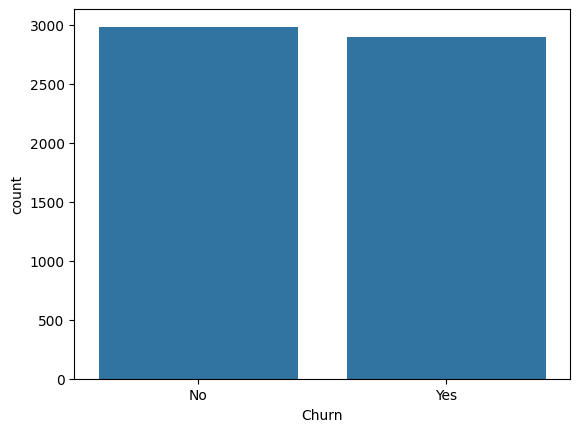

In [13]:
sns.countplot(x="Churn", data=df)
plt.show()

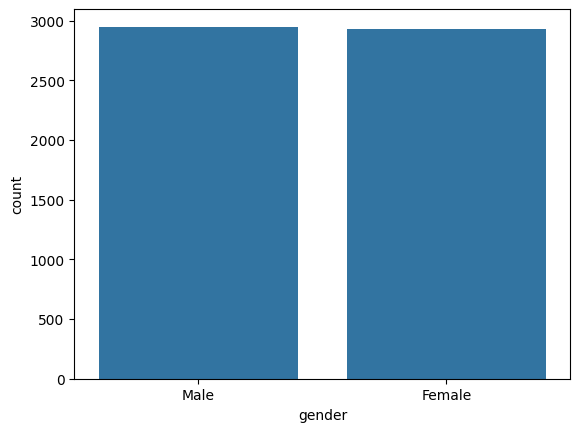

In [14]:
sns.countplot(x="gender", data=df)
plt.show()

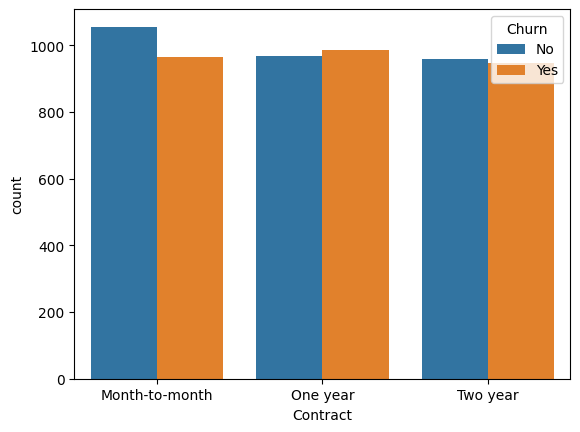

In [15]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

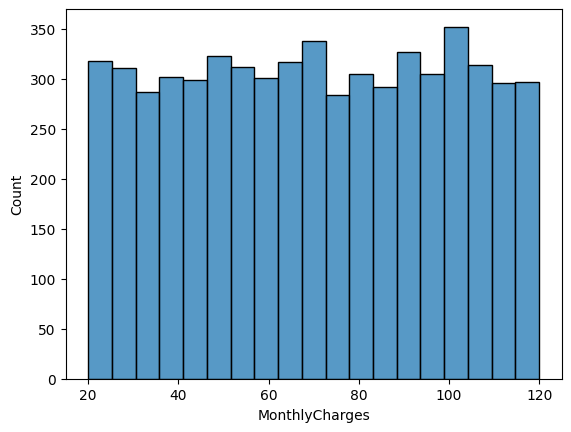

In [16]:
sns.histplot(df["MonthlyCharges"])
plt.show()

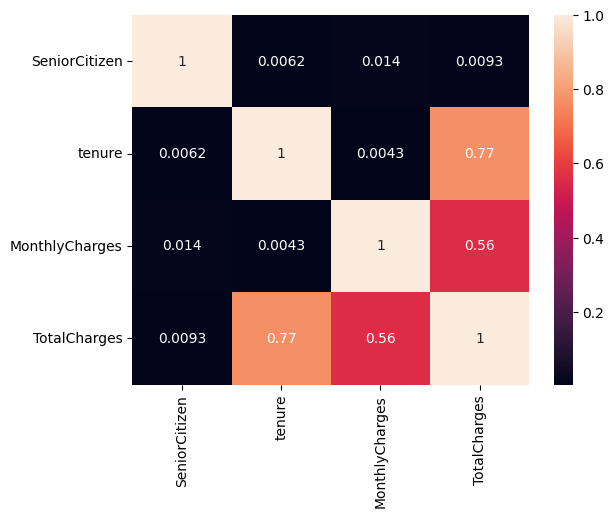

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df.fillna(df.mode().iloc[0], inplace=True)

In [20]:
df.fillna(df.median(numeric_only=True), inplace=True)

<Axes: ylabel='MonthlyCharges'>

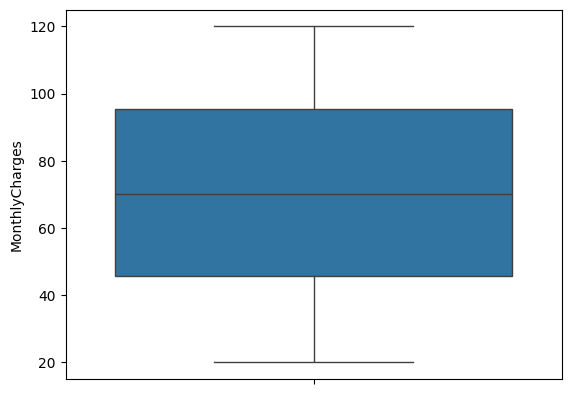

In [21]:
sns.boxplot(df["MonthlyCharges"])

In [22]:
Q1=df["MonthlyCharges"].quantile(0.25)
Q3=df["MonthlyCharges"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df["MonthlyCharges"]>lower)&(df["MonthlyCharges"]<upper)]

In [23]:
encoder=LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

In [24]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

In [25]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

In [26]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [27]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

In [28]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

In [29]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [30]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

In [31]:
models={
"Logistic":pred_lr,
"DecisionTree":pred_dt,
"RandomForest":pred_rf,
"KNN":pred_knn
}

for name,pred in models.items():

    print(name)

    print("Accuracy:",accuracy_score(y_test,pred))

    print(confusion_matrix(y_test,pred))

    print(classification_report(y_test,pred))

Logistic
Accuracy: 0.4906462585034014
[[369 215]
 [384 208]]
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       584
           1       0.49      0.35      0.41       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.48      1176
weighted avg       0.49      0.49      0.48      1176

DecisionTree
Accuracy: 0.5034013605442177
[[289 295]
 [289 303]]
              precision    recall  f1-score   support

           0       0.50      0.49      0.50       584
           1       0.51      0.51      0.51       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176

RandomForest
Accuracy: 0.4897959183673469
[[330 254]
 [346 246]]
              precision    recall  f1-score   support

           0       0.49      0.57      0.52       584
           1       0.49      0.42      0.45   

In [32]:
joblib.dump(rf,"churn_model.pkl")

['churn_model.pkl']

In [33]:
model=joblib.load("churn_model.pkl")

In [35]:
!pip install streamlit
import streamlit as st
import joblib
import numpy as np

model=joblib.load("churn_model.pkl")

st.title("Customer Churn Prediction")

tenure=st.number_input("Tenure")
monthly=st.number_input("Monthly Charges")
total=st.number_input("Total Charges")

if st.button("Predict"):

    data=np.array([[tenure,monthly,total]])

    prediction=model.predict(data)

    if prediction[0]==1:
        st.error("Customer will Churn")
    else:
        st.success("Customer will Stay")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.8 MB/s eta 0:00:00


2026-08-08 06:35:01.957 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.155 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-08 06:35:02.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.163 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 06:35:02.165 Session state does not 

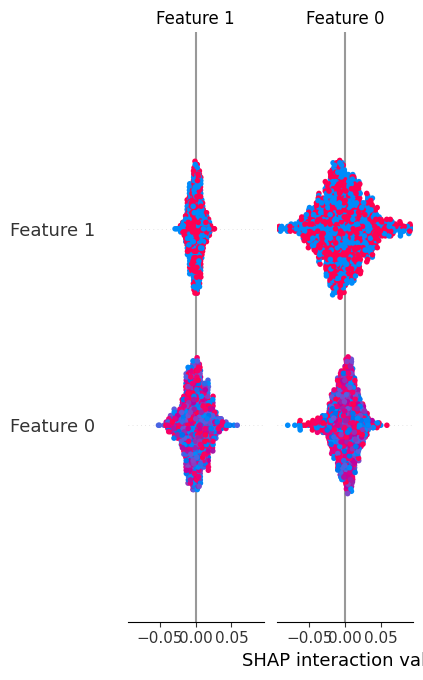

In [36]:
import shap

explainer=shap.TreeExplainer(rf)

values=explainer.shap_values(X_test)

shap.summary_plot(values,X_test)

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,10,20]
}

grid=GridSearchCV(
RandomForestClassifier(),
param_grid,
cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}
